In [1]:
import pandas as pd

# Загрузка Excel
df = pd.read_excel("../data/vk_posts_raw.xlsx")

# Переименование колонок
df.columns = ["post_id", "publish_date", "views", "likes", "comments", "post_text"]

# Обработка даты
df["publish_date"] = pd.to_datetime(df["publish_date"])
df["weekday"] = df["publish_date"].dt.dayofweek
df["hour"] = df["publish_date"].dt.hour

# Признаки из текста
df["text_length"] = df["post_text"].fillna("").apply(len)
df["word_count"] = df["post_text"].fillna("").apply(lambda x: len(x.split()))

# Оставляем только нужные переменные
X = df[[
    "post_id",         # <- index
    "weekday",
    "hour",
    "comments",
    "text_length",
    "word_count"
]]

# Создаём бинарные таргеты
like_threshold = df["likes"].median()
view_threshold = df["views"].median()

df["target_like"] = (df["likes"] > like_threshold).astype(int)
df["target_view"] = (df["views"] > view_threshold).astype(int)

y = df[[
    "post_id",       # <- index
    "target_like",
    "target_view"
]]

# Сохранение CSV
X.to_csv("../data/X.csv", index=False, sep=",", float_format="%.3f")
y.to_csv("../data/y.csv", index=False, sep=",", float_format="%.3f")

print("✅ X.csv и y.csv успешно созданы по требованиям платформы.")


✅ X.csv и y.csv успешно созданы по требованиям платформы.


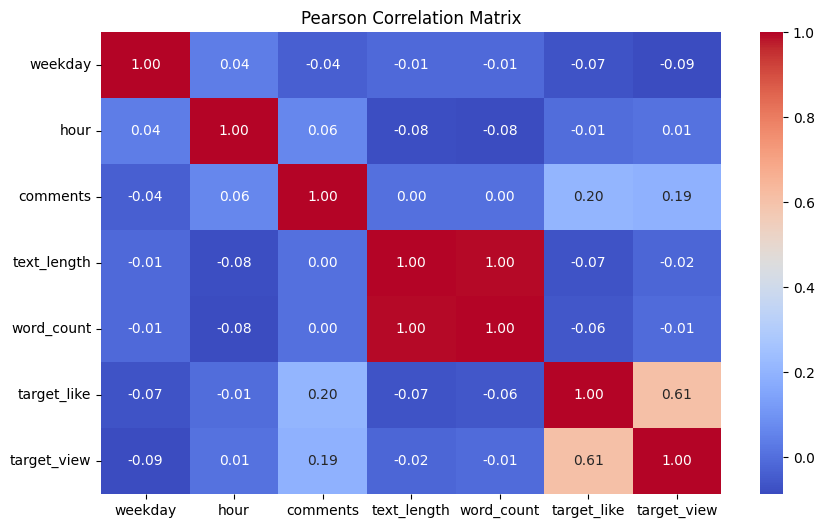

Accuracy: 0.64
F1 Score: 0.6343115124153499
ROC AUC: 0.6864766738153617

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.65      0.65      1366
           1       0.64      0.63      0.63      1334

    accuracy                           0.64      2700
   macro avg       0.64      0.64      0.64      2700
weighted avg       0.64      0.64      0.64      2700


Confusion Matrix:
 [[885 481]
 [491 843]]


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Загрузка
X = pd.read_csv("../data/X.csv")
y = pd.read_csv("../data/y.csv")

# 2. Объединение по post_id
df = pd.merge(X, y, on="post_id")

# 3. Матрица корреляций Пирсона
corr_matrix = df.drop(columns=["post_id"]).corr(method="pearson")
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Matrix")
plt.show()

# 4. Подготовка фичей и таргета
features = ["weekday", "hour", "comments", "text_length", "word_count"]
X_data = df[features]
y_data = df["target_like"]  # Можно поменять на "target_view"

# 5. Трен/тест-сплит
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=42, stratify=y_data
)

# 6. Модель Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 7. Оценка модели
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Загрузка данных
X = pd.read_csv("../data/X.csv")
y = pd.read_csv("../data/y.csv")

# Объединение по post_id
df = pd.merge(X, y, on="post_id")

# Подготовка данных
features = ["weekday", "hour", "comments", "text_length", "word_count"]
X_data = df[features]
y_data = df["target_view"]

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=42, stratify=y_data
)

# Обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Метрики
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_test = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Ошибки 1 и 2 рода
# P1: False Positive Rate (FP / (FP + TN))
# P2: False Negative Rate (FN / (FN + TP))
tn, fp, fn, tp = conf_matrix.ravel()
error_p1_test = fp / (fp + tn)
error_p2_test = fn / (fn + tp)

# Частота таргета
rate_target_test = y_test.mean()
rate_target_train = y_train.mean()

{
    "AUC_train": round(auc_train, 3),
    "AUC_test": round(auc_test, 3),
    "F1_score": round(f1, 3),
    "Accuracy": round(accuracy, 3),
    "Error_P1_test": round(error_p1_test, 3),
    "Error_P2_test": round(error_p2_test, 3),
    "Rate_target_test": round(rate_target_test, 3),
    "Rate_target_train": round(rate_target_train, 3),
    "Count_variables": len(features)
}



{'AUC_train': 0.995,
 'AUC_test': 0.668,
 'F1_score': 0.619,
 'Accuracy': 0.616,
 'Error_P1_test': np.float64(0.391),
 'Error_P2_test': np.float64(0.377),
 'Rate_target_test': np.float64(0.5),
 'Rate_target_train': np.float64(0.5),
 'Count_variables': 5}